In [1]:
import matplotlib.pyplot as plt

Przetwarzanie grupy: Gamma 0.9...
Filtr 'g0.9_run': Znaleziono 10 folderów.
Przetwarzanie grupy: Gamma 0.99...
Filtr 'g0.99_run': Znaleziono 10 folderów.
Przetwarzanie grupy: Gamma 0.999...
Filtr 'g0.999_run': Znaleziono 10 folderów.

Wykres porównawczy został zapisany jako 'porownanie_gamma.png'


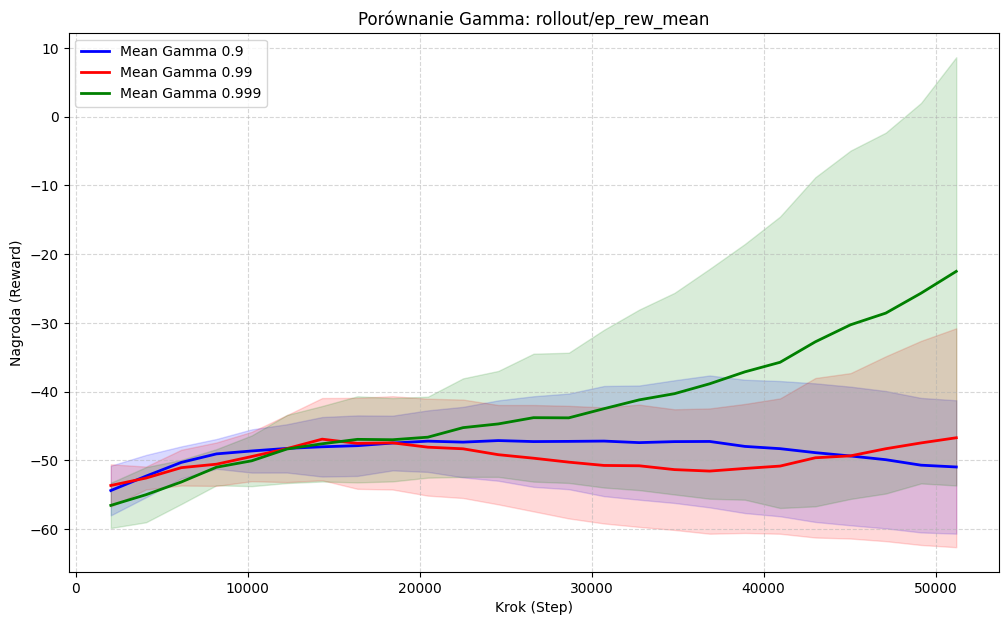

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def get_logs_data_filtered(logdir, tag_name, filter_str):
    """Wyciąga dane dla tagu tylko z folderów zawierających filter_str."""
    all_runs_data = []
    
    # Pobieramy wszystkie podfoldery
    all_folders = [d for d in os.listdir(logdir) if os.path.isdir(os.path.join(logdir, d))]
    # Filtrujemy te, które pasują do naszej gammy (np. 'g09')
    target_folders = [os.path.join(logdir, d) for d in all_folders if filter_str in d]
    
    print(f"Filtr '{filter_str}': Znaleziono {len(target_folders)} folderów.")

    for run_path in target_folders:
        event_acc = EventAccumulator(run_path)
        event_acc.Reload()
        
        if tag_name in event_acc.Tags()['scalars']:
            events = event_acc.Scalars(tag_name)
            steps = [e.step for e in events]
            values = [e.value for e in events]
            all_runs_data.append(pd.Series(values, index=steps))
            
    return all_runs_data

def plot_comparison(logdir, tag_name, experiments):
    plt.figure(figsize=(12, 7))
    
    # Kolory dla poszczególnych linii
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    
    for (label, filter_str), color in zip(experiments.items(), colors):
        print(f"Przetwarzanie grupy: {label}...")
        data_series = get_logs_data_filtered(logdir, tag_name, filter_str)
        
        if not data_series:
            print(f"  Brak danych dla {label}")
            continue
            
        # Łączymy dane i liczymy statystyki
        df = pd.concat(data_series, axis=1)
        # Opcjonalnie: wygładzanie danych (rolling mean), jeśli wykres jest zbyt "poszarpany"
        mean = df.mean(axis=1)
        std = df.std(axis=1)
        steps = df.index

        # Rysowanie linii średniej
        plt.plot(steps, mean, label=f'Mean {label}', color=color, linewidth=2)
        # Rysowanie obszaru odchylenia
        plt.fill_between(steps, mean - std, mean + std, color=color, alpha=0.15)

    plt.title(f'Porównanie Gamma: {tag_name}')
    plt.xlabel('Krok (Step)')
    plt.ylabel('Nagroda (Reward)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.savefig('porownanie_gamma.png')
    print("\nWykres porównawczy został zapisany jako 'porownanie_gamma.png'")
    plt.show()

# --- KONFIGURACJA ---
PATH_TO_LOGS = 'logs2/' # Zmień na swój folder
TAG_TO_PLOT = 'rollout/ep_rew_mean' 

# Definicja eksperymentów: { 'Etykieta na wykresie': 'fragment_nazwy_folderu' }
# Dopasuj te nazwy do tego, co masz w tb_log_name
EXPERIMENTS = {
    'Gamma 0.9': 'g0.9_run',
    'Gamma 0.99': 'g0.99_run',   # szuka folderów z g99_cont
    'Gamma 0.999': 'g0.999_run'
}

plot_comparison(PATH_TO_LOGS, TAG_TO_PLOT, EXPERIMENTS)